# Running your first Simulation

Now that we know how to create a `Grid` and a `State`, let's see how to advance that state in time. To do this, we use the `Solver` class.

## 1. Setup

Let's recreate our grid and state from the previous tutorial.

In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

from saetass import units as su
from saetass.grid import Grid
from saetass.solver import Solver
from saetass.state import State
from saetass.utils.energy_losses import Particle

# Create a spatial grid, evolved during 1 Myr in 100 timesteps
grid = Grid.uniform(
    r_min=0.0 * u.pc,
    r_max=10.0 * u.pc,
    num_r_cells=100,
    t_min=0.0 * u.Myr,
    t_max=1.0 * u.Myr,
    num_timesteps=100,
)

# Create an initial state: a localized burst at the center
r = grid.r_centers
psi_initial = np.exp(-((r - 5.0 * u.pc) ** 2) / (2 * (0.2 * u.pc) ** 2))
state = State(
    grid, psi_p=psi_initial * u.cm**-3 / su.MOMENTUM, particle=Particle.PROTON
)

## 2. Configuring the Solver

The `Solver` needs to know:
1. Which physical processes to solve (**problem_type**).
2. The parameters for those processes (**operator_params**).

Physical parameters are given as Quantities, in any compatible unit, and SAETASS converts them to its canonical units. Let's simulate a simple **Diffusion** problem.

In [2]:
# Define the problem: only diffusion
problem_type = "diffusion"

# Set a constant diffusion coefficient of 1 pc^2/Myr (about 3e23 cm^2/s)
# D_values must match the grid shape (num_cells_r,)
D_const = 1.0 * u.pc**2 / u.Myr
D_values = np.full(grid.num_cells_r, D_const.value) * D_const.unit

operator_params = {"diffusion": {"D_values": D_values}}

# Instantiate the solver
solver = Solver(
    grid=grid, state=state, problem_type=problem_type, operator_params=operator_params
)

╭─ SAETASS: Solver for Astroparticle Equation of Transport Analysis in Spherical Symmetry ─╮              
              │                                                                                          │              
              │                                     :::::::::::::::                                      │              
              │                                 :::::::::::::::::::::::                                  │              
              │                               :::::::::++++++++++::::::::                                │              
              │                              ::::::::++++++++++++++::::::::                              │              
              │                             :::::::++++++++++++++++++:::::::                             │              
              │                            ::::::::++++++++++++++++++::::::::                            │              
              │                            :::::::++++++++++++++++++++:::::::                            │              
              │                            :::::::+++++++++++++++++++::::::::                            │              
              │                            ::::::::++++++++++++++++++::::::::                            │              
              │                             ::::::::::++++++++++++++                                     │              
              │                              :::::::::::::::++++++                                       │              
              │                                :::::::::::::::::::::                                     │              
              │                                   ::::::::::::::::::::::                                 │              
              │                                       ++:::::::::::::::::::                              │              
              │                                     ++++++++++++::::::::::::                             │              
              │                                   ++++++++++++++++++:::::::::                            │              
              │                           ::::::::++++++++++++++++++++::::::::                           │              
              │                           :::::::++++++++++++++++++++++:::::::                           │              
              │                           :::::::++++++++++++++++++++++:::::::                           │              
              │                            :::::::++++++++++++++++++++:::::[

## 3. Advancing in Time

SAETASS allows you to run simulations in two ways:
- `solver.run()`: Runs the entire simulation until `t_max`.
- `solver.step(n)`: Advances by `n` time steps.

Let's use `step()` to see the evolution progressively.

Output()

Output()

Output()

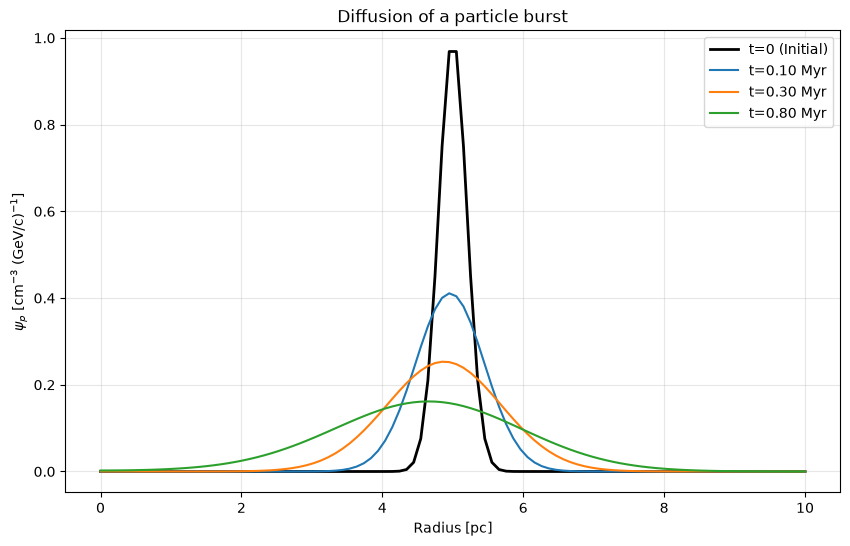

In [3]:
psi_unit = u.cm**-3 / su.MOMENTUM
r_pc = grid.r_centers.to_value(u.pc)

plt.figure(figsize=(10, 6))
plt.plot(
    r_pc, state.psi_p.to_value(psi_unit), label="t=0 (Initial)", lw=2, color="black"
)

# Run for some steps and plot intermediate results
for steps in [10, 20, 50]:
    solver.step(steps)
    plt.plot(r_pc, state.psi_p.to_value(psi_unit), label=f"t={state.t:.2f}")

plt.xlabel("Radius [pc]")
plt.ylabel(r"$\psi_p$ [cm$^{-3}$ (GeV/c)$^{-1}$]")
plt.title("Diffusion of a particle burst")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Why does this happen?

As we can see, the initial narrow spike spreads out over time. This is exactly what the Diffusion operator does: it smooths out gradients in the distribution function. 

Notice how the **area under the curve** is conserved? SAETASS uses a Finite Volume approach to ensure that particles are not lost during transport.

## Summary

In this tutorial, you learned:
1. How to define a **problem type**.
2. How to pass physical **parameters**, with units, to specific operators.
3. How to **advance** the simulation using `step()`.

In the next tutorial, we will explore more complex physics like combined **Advection-Diffusion** and adding a **Source**!